In [13]:
# 1. Open the file
f = open("jds.txt", encoding="utf-8")
# 2. Read the entire text

text = f.read()
# 3. Print the length of the LIST, not the string
print(len(text))

103908


In [14]:
# Split the whole text wherever the marker appears.
# This gives a list: ['', 'JD 1 text...', 'JD 2 text...', ...]
jds = text.split("=== JD ===")
# Drop the empty first piece and tidy the rest.
# .strip() removes blank lines and spaces at the start/end of each JD.
# The "if p.strip()" part keeps only pieces that still have text in them —
# so if you ever leave a stray marker in the file, the empty piece is ignored.
jds = [p.strip() for p in jds if p.strip()]

# Confirm we now have 22.
print("Number of JDs:", len(jds))

Number of JDs: 23


In [15]:
!pip install -q google-genai

In [21]:
from google import genai
from google.colab import userdata

# 1. Fetch the key from the vault invisibly
client = genai.Client(api_key=userdata.get("GOOGLE_API_KEY"))

# 2. Send a test message to Gemini
response = client.models.generate_content(
    model="gemini-3.8-flash",
    contents="Say hello in one short sentence."
)

# 3. Print what Gemini says back
print(response.text)

Hello, it is wonderful to meet you!


In [23]:
prompt = f"""You are analysing a job description to extract the skills it requires.

Rules:
- List only skills explicitly mentioned or clearly implied by the text.
- Use short, standard names: "SQL", "stakeholder management", "prompt engineering".
- Do not invent skills that aren't there.
- Do not include years of experience, degrees, or company names.
- Return 5 to 15 skills.
- Include tools, methods, and techniques, not just broad competencies.
- Check the "preferred qualifications" and responsibilities sections line by line; skills are often buried mid-sentence.

Return ONLY a JSON array of strings, nothing else. Example:
["SQL", "stakeholder management", "process mapping"]

Job description:
{jds[0]}
"""

response = client.models.generate_content(
    model="gemini-3.8-flash",
    contents=prompt
)

print(response.text)

[
  "program management",
  "change management",
  "stakeholder management",
  "prompt engineering",
  "AI agent design",
  "AI evaluation",
  "AI ethics",
  "low-code/no-code AI",
  "process redesign",
  "ROI modeling",
  "cross-functional collaboration",
  "AI deployment"
]


Run 1 - gemini-3.8-flash. Hit the free-tier daily cap at JD 18; 14 of 23 extracted. Kept for model comparison.

In [32]:
import json, time

all_skills = []  #one entry per JD
failed =[] #JDs where something went wrong

for i, jd in enumerate(jds):
  prompt = f"""You are analysing a job description to extract the skills it requires.

  Rules:
- List only skills explicitly mentioned or clearly implied by the text.
- Use short, standard names: "SQL", "stakeholder management", "prompt engineering".
- Do not invent skills that aren't there.
- Do not include years of experience, degrees, or company names.
- Return 5 to 15 skills.
- Include tools, methods, and techniques, not just broad competencies.
- Check the "preferred qualifications" and responsibilities sections line by line; skills are often buried mid-sentence.

Return ONLY a JSON array of strings, nothing else. Example:
["SQL", "stakeholder management", "process mapping"]

Job description:
{jd}
"""
  try:
        r = client.models.generate_content(model="gemini-3.8-flash", contents=prompt)
        raw = r.text.strip()

        # Gemini often wraps JSON in ```json ... ``` — strip that off
        raw = raw.replace("```json", "").replace("```", "").strip()

        skills = json.loads(raw)        # text → real Python list
        all_skills.append(skills)
        print(i + 1, "OK -", len(skills), "skills")

  except Exception as e:
        failed.append(i)
        all_skills.append([])           # keep positions aligned
        print(i + 1, "FAILED -", e)

  time.sleep(2)                       # be polite to the free tier

print("\nDone. Failures:", failed)



1 OK - 12 skills
2 FAILED - 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
3 OK - 13 skills
4 OK - 12 skills
5 OK - 12 skills
6 OK - 12 skills
7 FAILED - 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
8 OK - 12 skills
9 OK - 10 skills
10 OK - 11 skills
11 OK - 12 skills
12 OK - 12 skills
13 OK - 14 skills
14 OK - 13 skills
15 FAILED - 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
16 OK - 12 skills
17 OK - 12 skills
18 FAILED - 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and bill

In [33]:
for m in client.models.list():
    print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-nano-banana-2.1
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-omni-1.1-flash
models/gemini-3.5-transcribe
models/gemini-3.6-flash
models/gemini-3.7-flash
models/gemini-3.8-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/lyria-3.5
models/gemini

In [38]:
MODEL = "gemini-3.5-flash-lite"

rules = """You are analysing a job description to extract the skills it requires.

Rules:
- List only skills explicitly mentioned or clearly implied by the text.
- Use short, standard names: "SQL", "stakeholder management", "prompt engineering".
- Do not invent skills that aren't there.
- Do not include years of experience, degrees, or company names.
- Return 5 to 15 skills.
- Include tools, methods, and techniques, not just broad competencies.
- Check the "preferred qualifications" and responsibilities sections line by line; skills are often buried mid-sentence.

Return ONLY a JSON array of strings, nothing else."""

r = client.models.generate_content(
    model=MODEL,
    contents=f"{rules}\n\nJob description:\n{jds[0]}"
)
print(r.text)

[
  "program management",
  "change management",
  "stakeholder management",
  "no-code/low-code AI tools",
  "AI/ML solution development",
  "workflow design",
  "prompt engineering",
  "ROI modeling",
  "business operations",
  "cross-functional collaboration"
]


In [37]:
import json, time

all_skills2 = []
failed2 = []

for i, jd in enumerate(jds):
    try:
        r = client.models.generate_content(
            model=MODEL,
            contents=f"{rules}\n\nJob description:\n{jd}"
        )
        raw = r.text.replace("```json", "").replace("```", "").strip()
        all_skills2.append(json.loads(raw))
        print(i + 1, "OK -", len(all_skills2[-1]), "skills")
    except Exception as e:
        failed2.append(i)
        all_skills2.append([])
        print(i + 1, "FAILED -", e)
    time.sleep(6)

print("\nDone. Failures:", failed2)

1 OK - 11 skills
2 OK - 10 skills
3 OK - 15 skills
4 OK - 13 skills
5 OK - 12 skills
6 OK - 13 skills
7 OK - 15 skills
8 OK - 13 skills
9 OK - 10 skills
10 OK - 13 skills
11 OK - 13 skills
12 OK - 14 skills
13 OK - 15 skills
14 OK - 15 skills
15 OK - 14 skills
16 OK - 14 skills
17 OK - 11 skills
18 OK - 12 skills
19 OK - 15 skills
20 OK - 14 skills
21 OK - 15 skills
22 OK - 15 skills
23 OK - 15 skills

Done. Failures: []


In [40]:
import json
with open("skills_run2.json", "w") as f:
    json.dump(all_skills2, f)
from google.colab import files
files.download("skills_run2.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
# Load the saved extraction so everything below runs without API calls
import json
all_skills2 = json.load(open("skills_run2.json"))
print(len(all_skills2), "job descriptions loaded")

23 job descriptions loaded


In [41]:
from collections import Counter

counts = Counter()
for skills in all_skills2:
    for s in skills:
        counts[s.lower().strip()] += 1

print("Unique skills:", len(counts))
print()
for skill, n in counts.most_common(25):
    print(n, "-", skill)

Unique skills: 206

21 - stakeholder management
10 - prompt engineering
9 - generative ai
6 - product management
5 - llms
5 - python
4 - langchain
4 - ai agents
4 - langgraph
3 - nlp
3 - claude
3 - rag
3 - workflow automation
3 - product roadmap
3 - large language models (llms)
3 - cross-functional collaboration
3 - business analysis
3 - go-to-market strategy
2 - change management
2 - workflow design
2 - openai
2 - agile
2 - backlog management
2 - risk management
2 - genai


In [42]:
for skill, n in counts.most_common():
    if n >= 2:
        print(n, "-", skill)

21 - stakeholder management
10 - prompt engineering
9 - generative ai
6 - product management
5 - llms
5 - python
4 - langchain
4 - ai agents
4 - langgraph
3 - nlp
3 - claude
3 - rag
3 - workflow automation
3 - product roadmap
3 - large language models (llms)
3 - cross-functional collaboration
3 - business analysis
3 - go-to-market strategy
2 - change management
2 - workflow design
2 - openai
2 - agile
2 - backlog management
2 - risk management
2 - genai
2 - user stories
2 - data analytics
2 - digital transformation
2 - product lifecycle management
2 - competitive analysis
2 - content strategy
2 - automation
2 - product marketing
2 - sales enablement
2 - market research
2 - retrieval-augmented generation
2 - sql
2 - project management
2 - mlops
2 - azure ai foundry
2 - tensorflow
2 - pytorch


In [59]:
ALIASES = {
    "genai": "generative ai",
    "gen ai": "generative ai",
    "large language models (llms)": "llms",
    "large language models": "llms",
    "llm": "llms",
    "automation" : "workflow automation"
    # add more as you spot them
}

clean = Counter()
for skills in all_skills2:
    for s in skills:
        s = s.lower().strip()
        s = ALIASES.get(s, s)      # swap if it's an alias, else keep
        clean[s] += 1

print("Unique after merging:", len(clean))
for skill, n in clean.most_common(20):
    print(n, "-", skill)

Unique after merging: 202
21 - stakeholder management
11 - generative ai
10 - prompt engineering
9 - llms
6 - product management
5 - workflow automation
5 - python
4 - langchain
4 - ai agents
4 - langgraph
3 - nlp
3 - claude
3 - rag
3 - product roadmap
3 - cross-functional collaboration
3 - business analysis
3 - go-to-market strategy
2 - change management
2 - workflow design
2 - openai


In [63]:
ALIASES.update({
    "retrieval augmented generation": "rag",
    "retrieval-augmented generation": "rag",
})

In [71]:
CATEGORY = {
    # Business & communication
    "stakeholder management": "Business & Communication",
    "cross-functional collaboration": "Business & Communication",
    "change management": "Business & Communication",
    "business analysis": "Business & Communication",
    "digital transformation": "Business & Communication",
    "risk management": "Business & Communication",
    "go-to-market strategy": "Business & Communication",
    "competitive analysis": "Business & Communication",
    "market research": "Business & Communication",
    "product marketing": "Business & Communication",
    "sales enablement": "Business & Communication",
    "content strategy": "Business & Communication",

    # Product & delivery
    "product management": "Product & Delivery",
    "product roadmap": "Product & Delivery",
    "backlog management": "Product & Delivery",
    "user stories": "Product & Delivery",
    "agile": "Product & Delivery",
    "workflow automation": "Product & Delivery",
    "workflow design": "Product & Delivery",
    "project management": "Product & Delivery",
    "program management": "Product & Delivery",

    # GenAI concepts
    "generative ai": "GenAI Concepts",
    "llms": "GenAI Concepts",
    "rag": "GenAI Concepts",
    "ai agents": "GenAI Concepts",
    "prompt engineering": "GenAI Concepts",
    "nlp": "GenAI Concepts",

    # Tools & frameworks
    "langchain": "Tools & Frameworks",
    "langgraph": "Tools & Frameworks",
    "claude": "Tools & Frameworks",
    "openai": "Tools & Frameworks",
    "azure ai foundry": "Tools & Frameworks",

    # Engineering & data
    "python": "Engineering & Data",
    "sql": "Engineering & Data",
    "mlops": "Engineering & Data",
    "tensorflow": "Engineering & Data",
    "pytorch": "Engineering & Data",
    "data analytics": "Engineering & Data",
}


# Add the three merges to your existing ALIASES
ALIASES.update({
    "retrieval-augmented generation": "rag",
    "automation": "workflow automation",
    "product lifecycle management": "product management",
})

clean = Counter()
by_category = Counter()
uncategorised = Counter()

for skills in all_skills2:
    for s in skills:
        s = ALIASES.get(s.lower().strip(), s.lower().strip())
        clean[s] += 1

        cat = CATEGORY.get(s)
        if cat:
            by_category[cat] += 1
        else:
            uncategorised[s] += 1

print("TOP 15 SKILLS")
for skill, n in clean.most_common(15):
    print(" ", n, "-", skill)

print("\nBY CATEGORY")
for cat, n in by_category.most_common():
    print(" ", n, "-", cat)

print("\nNOT YET CATEGORISED (top 15)")
for skill, n in uncategorised.most_common(15):
    print(" ", n, "-", skill)

TOP 15 SKILLS
  21 - stakeholder management
  11 - generative ai
  10 - prompt engineering
  9 - llms
  8 - product management
  5 - rag
  5 - workflow automation
  5 - python
  4 - langchain
  4 - ai agents
  4 - langgraph
  3 - nlp
  3 - claude
  3 - product roadmap
  3 - cross-functional collaboration

BY CATEGORY
  46 - Business & Communication
  42 - GenAI Concepts
  27 - Product & Delivery
  15 - Tools & Frameworks
  15 - Engineering & Data

NOT YET CATEGORISED (top 15)
  1 - global operations
  1 - no-code/low-code ai tools
  1 - ai/ml deployment
  1 - ethical ai
  1 - roi modeling
  1 - business requirements gathering
  1 - promptlayer
  1 - chatgpt
  1 - copilot
  1 - azure ai
  1 - user story writing
  1 - agile product management
  1 - ai product strategy
  1 - roadmap management
  1 - technical requirements


In [73]:
jd_coverage = Counter()

for skills in all_skills2:
    cats_in_this_jd = set()                      # set = no duplicates
    for s in skills:
        s = ALIASES.get(s.lower().strip(), s.lower().strip())
        cat = CATEGORY.get(s)
        if cat:
            cats_in_this_jd.add(cat)
    for c in cats_in_this_jd:
        jd_coverage[c] += 1

print("CATEGORY COVERAGE (out of 23 JDs)")
for cat, n in jd_coverage.most_common():
    print(f"  {n}/23 ({round(n/23*100)}%) - {cat}")

CATEGORY COVERAGE (out of 23 JDs)
  21/23 (91%) - Business & Communication
  16/23 (70%) - GenAI Concepts
  13/23 (57%) - Product & Delivery
  8/23 (35%) - Tools & Frameworks
  8/23 (35%) - Engineering & Data


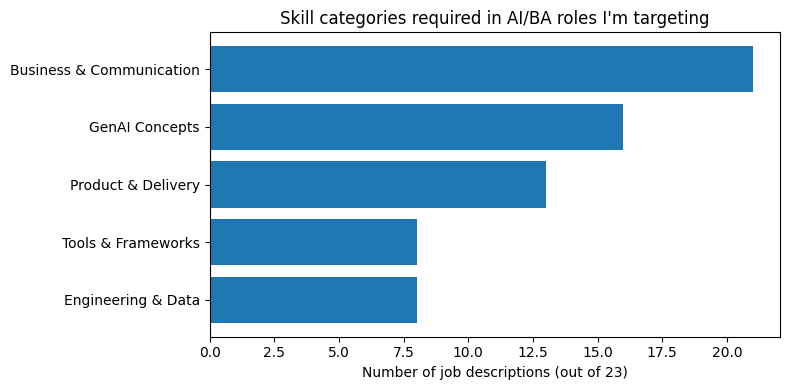

In [74]:
import matplotlib.pyplot as plt

cats = [c for c, n in jd_coverage.most_common()]
vals = [n for c, n in jd_coverage.most_common()]

plt.figure(figsize=(8, 4))
plt.barh(cats[::-1], vals[::-1])          # reversed so biggest sits on top
plt.xlabel("Number of job descriptions (out of 23)")
plt.title("Skill categories required in AI/BA roles I'm targeting")
plt.tight_layout()
plt.savefig("skill_categories.png", dpi=150)
plt.show()

In [75]:
from google.colab import files
files.download("skill_categories.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>